In [13]:
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

root = Path('.')

vars = ['t2m', 'ssr', 'sf', 'rf']
var_names = {'t2m': 'Temperature \nanomaly (°C)', 
             'sf':'Snowfall \nanomaly (mm)', 
             'rf':'Rainfall \nanomaly (mm)', 
             'ssr': 'Solar radiation \nanomaly (W m⁻²)'}

In [14]:
# Calculate detrended correlations between lake ice phenology and AR frequency

from scipy.stats import pearsonr
from scipy import signal

iceons_short = pd.read_csv(root / 'iceons_short.csv', index_col=0)
iceoffs_short = pd.read_csv(root / 'iceoffs_short.csv', index_col=0)
iceds_short = pd.read_csv(root / 'iceds_short.csv', index_col=0)

AR_freq_iceons = pd.read_csv(root / 'AR_frequency_annual_AutWin.csv', index_col=0)
AR_freq_iceoffs = pd.read_csv(root / 'AR_frequency_annual_SprSum.csv', index_col=0)
AR_freq_durations = pd.read_csv(root / 'AR_frequency_annual_AllYear.csv', index_col=0)

def calcu_corr(lip, ar_var):
    corr_df = pd.DataFrame(index=lip.columns, columns=['r', 'p'])
    for col in lip.columns:
        df = pd.concat([lip[col], ar_var[col]], axis=1).dropna()
        df_detrended = df.apply(lambda x: signal.detrend(x, type='linear'))
        df_detrended = pd.DataFrame(df_detrended, index=df.index, columns=df.columns)

        if not df_detrended.empty:
            r, p = pearsonr(df_detrended.iloc[:,0], df_detrended.iloc[:,1])
            corr_df.loc[col, 'r'] = r
            corr_df.loc[col, 'p'] = p
        else:
            corr_df.loc[col, 'r'] = np.nan
            corr_df.loc[col, 'p'] = np.nan
    return corr_df

results1 = calcu_corr(iceons_short, AR_freq_iceons)
results2 = calcu_corr(iceoffs_short, AR_freq_iceoffs)
results3 = calcu_corr(iceds_short, AR_freq_durations)

results1_pref = results1.add_prefix('Iceon_AutWin_')
results2_pref = results2.add_prefix('Iceoff_SprSum_')
results3_pref = results3.add_prefix('Duration_AllYear_')

merged_results = pd.concat([results1_pref, results2_pref, results3_pref], axis=1)

merged_results.to_csv(root / 'LIP_AR_Freq_Corr_detrended_season.csv')
print(merged_results.head())

      Iceon_AutWin_r Iceon_AutWin_p Iceoff_SprSum_r Iceoff_SprSum_p  \
ARAI1        0.17675       0.214697       -0.132587         0.46944   
ASK01       0.361307       0.032964       -0.160262        0.357754   
DML1        0.131608       0.580205        0.120046        0.340835   
DMR1        0.053938       0.655058       -0.032293        0.789205   
DMR2         0.08622       0.474648        0.007065        0.953373   

      Duration_AllYear_r Duration_AllYear_p  
ARAI1          -0.144019           0.303552  
ASK01          -0.388667           0.006937  
DML1           -0.281901           0.228538  
DMR1            0.024717           0.837884  
DMR2            0.036274           0.763932  


In [15]:
# Calculate detrended correlations between lake ice phenology and AR-associated climate anomalies

def calcu_corr_by_var(var):
    iceons_short = pd.read_csv(root / 'iceons_short.csv', index_col=0)
    iceoffs_short = pd.read_csv(root / 'iceoffs_short.csv', index_col=0)
    iceds_short = pd.read_csv(root / 'iceds_short.csv', index_col=0)
    
    annual_data = pd.read_csv(root / f'AR_related_{var}_anom_ALLYear.csv', index_col=0)
    autumn_winter_data = pd.read_csv(root / f'AR_related_{var}_anom_AutWin.csv', index_col=0)
    spring_summer_data = pd.read_csv(root / f'AR_related_{var}_anom_SprSum.csv', index_col=0)
    
    results1 = calcu_corr(iceons_short, autumn_winter_data)
    results2 = calcu_corr(iceoffs_short, spring_summer_data)
    results3 = calcu_corr(iceds_short, annual_data)
    
    results1_pref = results1.add_prefix('Iceon_AutWin_')
    results2_pref = results2.add_prefix('Iceoff_SprSum_')
    results3_pref = results3.add_prefix('Duration_AllYear_')
    
    merged_results = pd.concat([results1_pref, results2_pref, results3_pref], axis=1)
    
    merged_results.to_csv(root / f'LIP_AR_related_{var}_Corr_detrended_season.csv')
    return 
    
for var in vars:
    calcu_corr_by_var(var)


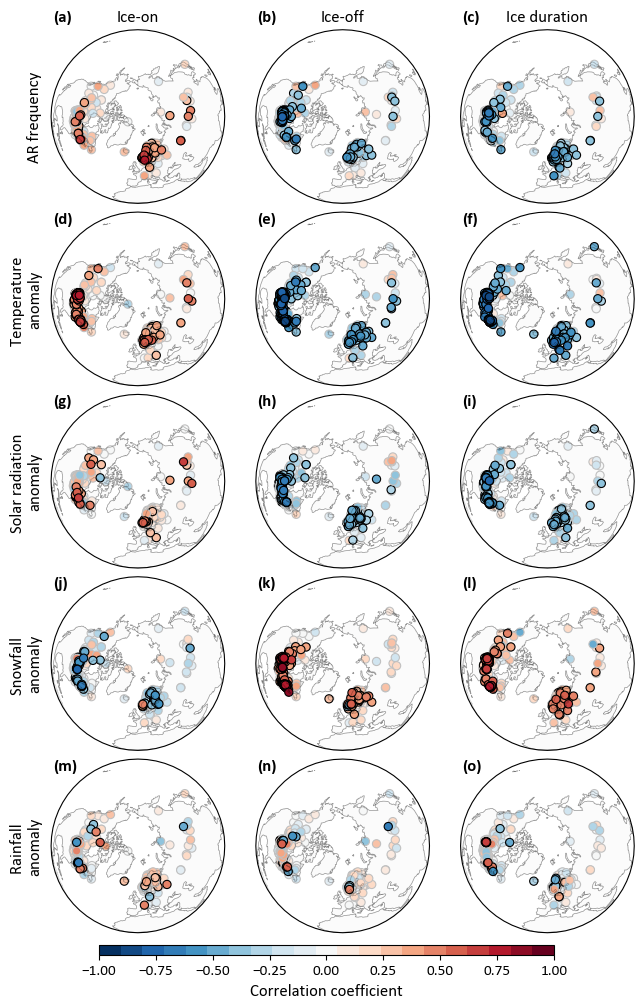

In [16]:
# Draw Figure 2

import cartopy.crs as ccrs
import cartopy.feature as cfeature

mpl.rcParams.update(mpl.rcParamsDefault)
proj = ccrs.Orthographic(0, 90)
mpl.rcParams.update({'font.size': 12, 'font.sans-serif': 'Calibri'})
fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(6.5, 10), subplot_kw={'projection': proj})
axes = axs.ravel()

for ii in range(15):
    axes[ii].add_feature(cfeature.LAND, facecolor='whitesmoke', edgecolor='grey', linewidth=0.5, alpha=0.3)
    axes[ii].add_feature(cfeature.COASTLINE, linewidth=0.5, alpha=0.3)
    axes[ii].set_global()
    if ii < 3:
        axes[ii].text(0.01, 1.11, '(%s)' % string.ascii_lowercase[ii], transform=axes[ii].transAxes, ha='left', va='top', fontweight='bold')
    else:
        axes[ii].text(0.01, 1, '(%s)' % string.ascii_lowercase[ii], transform=axes[ii].transAxes, ha='left', va='top', fontweight='bold')

cols1 = ["Iceon_AutWin_", "Iceoff_SprSum_", "Duration_AllYear_"]
cols2 = ["Ice-on", "Ice-off", "Ice duration"]
colormap = plt.cm.RdBu_r
colorrange = np.arange(-1,1.01,2/21)
norm = mpl.colors.BoundaryNorm(boundaries=colorrange, ncolors=colormap.N)

lake_info = pd.read_csv(root / 'Lake_info.csv', index_col=0)

def draw_figure(corrs, ii0):
    df0 = pd.concat([lake_info, corrs], axis=1)
    for ii in range(3):
        df1 = df0[['lon', 'lat', cols1[ii]+'r', cols1[ii]+'p']].copy()
        df1.dropna(inplace=True)
        df_sorted = df1.loc[df1[cols1[ii]+'r'].abs().sort_values(ascending=True).index]
        
        edgecolor = ['k' if df_sorted.loc[index, cols1[ii]+'p'] < 0.05 else 'silver' for index in df_sorted.index]
        axes[ii+ii0].scatter(df_sorted.lon, df_sorted.lat, c=df_sorted[cols1[ii]+'r'], 
                              cmap=colormap, s=35, norm=norm,
                              edgecolors=edgecolor, linewidths=0.8,
                              transform=ccrs.PlateCarree())
    return

# AR frequency
corrs = pd.read_csv(root / 'LIP_AR_Freq_Corr_detrended_season.csv', index_col=0)
draw_figure(corrs, 0)

# vars
for var, ii0 in zip(vars, [3, 6, 9, 12]):
    corrs = pd.read_csv(root / f'LIP_AR_related_{var}_Corr_detrended_season.csv', index_col=0)
    draw_figure(corrs, ii0)
    

cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.01])  
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=colormap), cax=cbar_ax, ticks= np.arange(-1,1.1,.25),
             orientation='horizontal', label='Correlation coefficient', extend='neither')
cbar.minorticks_off()
cbar.ax.tick_params(labelsize=11)  # 修改刻度字体大小
cbar.set_label('Correlation coefficient', fontsize=12)

axes[0].set_title('Ice-on', fontsize=12)
axes[1].set_title('Ice-off', fontsize=12)
axes[2].set_title('Ice duration', fontsize=12)

texts = ['AR frequency',
         'Temperature \nanomaly',
         'Solar radiation \nanomaly',
         'Snowfall \nanomaly',
         'Rainfall \nanomaly',]
for jj, tt in zip([0, 3, 6, 9, 12], texts):
    axes[jj].text(-0.05, 0.5, tt, transform=axes[jj].transAxes, ha='center', va='bottom', rotation=90, rotation_mode='anchor')


fig.subplots_adjust(bottom=0.072, top=0.975, left=0.06, right=0.99, wspace=0.05, hspace=0.05)
plt.show()

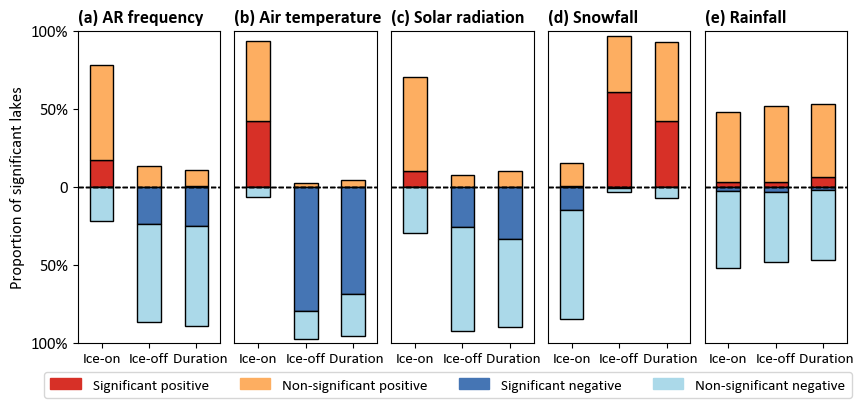

In [17]:
# Draw Figure S4

import matplotlib.patches as mpatches

var_names1 = ['AR frequency', 'Air temperature', 'Solar radiation', 'Snowfall', 'Rainfall']

mpl.rcParams.update({'font.size': 12, 'font.sans-serif': 'Calibri'})
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(8.5, 4))
axes = axs.ravel()

cols1 = ["Iceon_AutWin_", "Iceoff_SprSum_", "Duration_AllYear_"]
cols2 = ["Ice-on", "Ice-off", "Ice duration"]

def draw_figure(data, var_ii):
    for ii in range(3):
        ax = axes[var_ii]
        
        n = len(data.dropna(subset=[cols1[ii]+'r']))
        sig_po = len(data[(data[cols1[ii]+'p'] < 0.05) & (data[cols1[ii]+'r'] > 0)]) / n
        sig_ne = -len(data[(data[cols1[ii]+'p'] < 0.05) & (data[cols1[ii]+'r'] < 0)]) / n
        insig_po = len(data[(data[cols1[ii]+'p'] >= 0.05) & (data[cols1[ii]+'r'] > 0)]) / n
        insig_ne = -len(data[(data[cols1[ii]+'p'] >= 0.05) & (data[cols1[ii]+'r'] < 0)]) / n
        
        colors = {
        "Significant positive": "#d73027",   # 深红
        "Non-significant positive": "#fdae61", # 浅红
        "Significant negative": "#4575b4",   # 深蓝
        "Non-significant negative": "#abd9e9"  # 浅蓝
    }
    
        ax.bar(ii, sig_po, facecolor=colors['Significant positive'], edgecolor='k', width=0.5)
        ax.bar(ii, insig_po, bottom=sig_po, facecolor=colors["Non-significant positive"], edgecolor='k', width=0.5)
        ax.bar(ii, sig_ne, facecolor=colors["Significant negative"], edgecolor='k', width=0.5)
        ax.bar(ii, insig_ne, bottom=sig_ne, facecolor=colors["Non-significant negative"], edgecolor='k', width=0.5)
    
        ax.set_ylim((-1, 1))
        ax.axhline(y=0, linestyle='--', color='k', linewidth=1)
        ax.set_xlim((-0.5, 2.5))
        ax.set_yticks(np.linspace(-1, 1, 5), ['100%', '50%', 0, '50%', '100%'])
    
        ax.set_xticks([0, 1, 2], ['Ice-on', 'Ice-off', '  Duration'], fontsize=11)
    
        if var_ii == 0:
            ax.set_ylabel("Proportion of significant lakes")
        else:
            ax.set_yticks([])
        
        if var_ii == 0:
            handles = [mpatches.Patch(color=col, label=label) for label, col in colors.items()]
            ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(-0.29, -0.07), ncol=4, fontsize=11) 
        
        ax.set_title('(%s) ' % string.ascii_lowercase[var_ii] + var_names1[var_ii], loc='left', fontsize=13, fontweight='bold')


corrs = pd.read_csv(root / 'LIP_AR_Freq_Corr_detrended_season.csv', index_col=0)
draw_figure(corrs, 0)

for var, var_ii in zip(vars, range(1, 5)):
    data = pd.read_csv(root / f'LIP_AR_related_{var}_Corr_detrended_season.csv', index_col=0)
    draw_figure(data, var_ii)

fig.subplots_adjust(bottom=0.15, top=0.93, left=0.085, right=0.99, wspace=0.1)
plt.show()